In [1]:
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# 1 - 1 노트북 내 데이터 로드 및 데이터 구조(shape, info, 결측치 등) 확인 소스 코드와 출력 화면
df = pd.read_csv("diabetes.csv")

print("데이터 크기:", df.shape)
display(df.head())

print("\n변수 타입")
print(df.dtypes)

print("\n데이터 정보")
df.info()

print("\n일반 결측치")
print(df.isna().sum())

print("\n중복 행:", df.duplicated().sum())

print("\n기초 통계")
display(df.describe().T)

print("\n정답 클래스 분포")
display(
    df["Outcome"]
    .value_counts()
    .rename("count")
    .to_frame()
    .assign(ratio=lambda x: x["count"] / len(df))
)

zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

print("\n생리학적으로 부적절한 0값")
display((df[zero_as_missing] == 0).sum().rename("zero_count"))

데이터 크기: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



변수 타입
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

데이터 정보
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8  

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



정답 클래스 분포


,count,ratio
Outcome,,
0,500,0.651042
1,268,0.348958



생리학적으로 부적절한 0값


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Name: zero_count, dtype: int64

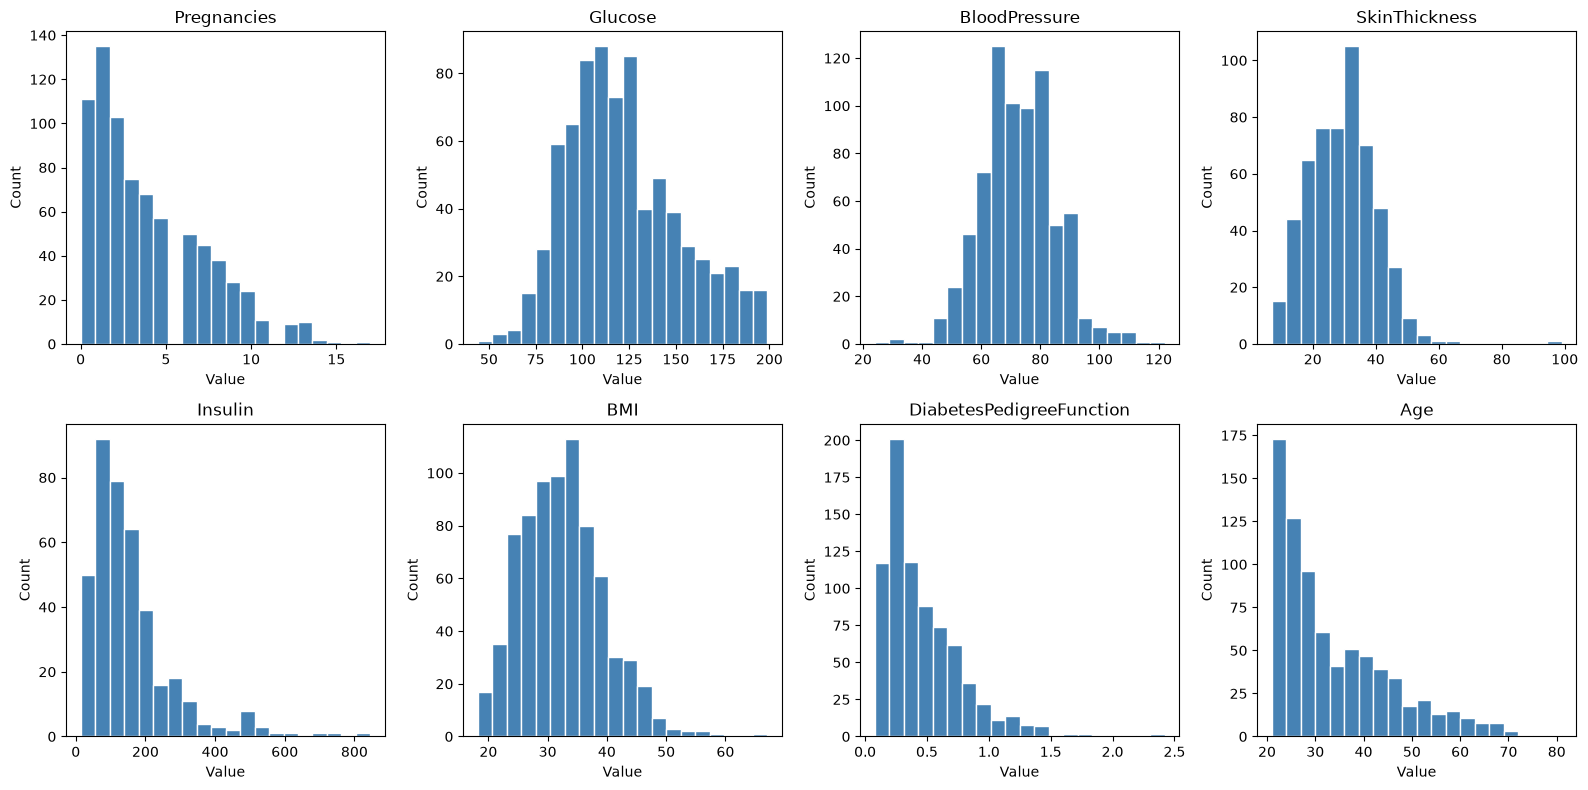

In [3]:
1 - 2 데이터의 분포 및 상관관계를 나타내는 시각화 차트 이미지와 데이터 특성 분석 내용 (마크다운 셀)

eda_df = df.copy()
eda_df[zero_as_missing] = eda_df[zero_as_missing].replace(0, np.nan)

feature_cols = eda_df.drop(columns="Outcome").columns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, column in zip(axes, feature_cols):
    ax.hist(
        eda_df[column].dropna(),
        bins=20,
        color="steelblue",
        edgecolor="white"
    )
    ax.set_title(column)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()